# **Project 3 − A Galton Board on a Rocking Ship**
## Advanced Simulation and Machine Learning | TIF345
## Chalmers University of Technology | Fall 2025
---
### Linus Brink | [brinkl@chalmers.se](mailto:brinkl@chalmers.se) 
### Oscar Stommendal | [oscarsto@chalmers.se](mailto:oscarsto@chalmers.se)
---

## **Setup**

In [604]:

# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from tqdm import tqdm
import seaborn as sns

# Latex plotting settings
plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'palatino'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}'
font_size = 14
plt.rcParams['font.size'] = font_size
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# General functions
def joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, cmap, truth_color, mean_color, ax=None):
    if ax is None:
        fig = plt.figure(figsize=(5, 3))
        ax = fig.gca()
    else:
        fig = plt.gcf()
    sns.histplot(weights=weights, x=alpha_samples, y=s_samples, bins=50, stat='density', cmap=cmap, cbar_kws={'label': 'Density', 'location': 'bottom', 'pad': 0.07})
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=5, width=1)
    plt.axvline(x=0.25, color=truth_color, linestyle='-', linewidth=2)
    plt.axhline(y=0.1, color=truth_color, linestyle='-', linewidth=2)
    plt.plot(0.25, 0.1, color=truth_color, marker='o', fillstyle='none', markersize=12, markeredgewidth=2, label='True value', linewidth=2)
    plt.xlim(0, 0.5)
    # plt.ylim(-0.25, 0.25)
    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$s$')

    # cax = ax.inset_axes([0.03, 0.05, 0.05, 0.95])  # [left, bottom, width, height]
    # cax.tick_params(direction='out', length=5, width=1, color='white', labelcolor='white')
    # cbar = plt.colorbar(ax.collections[0], cax=cax)

    # Plot histograms on the sides (top and right)
    ax_top = fig.add_axes([0.125, 0.915, 0.77, 0.15])
    ax_top.hist(alpha_samples, bins=40, weights=weights, density=True, color='turquoise', edgecolor='black', alpha=0.8)
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.spines['left'].set_visible(False)
    ax_top.tick_params(direction='out', length=5, width=1)
    ax_top.tick_params(left=False)
    ax_top.set_yticklabels([])
    ax_top.set_xticklabels([])
    ax_top.axvline(x=0.25, color=truth_color, linestyle='-', linewidth=2)
    ax_top.axvline(x=alpha_mean, color=mean_color, linestyle='-', linewidth=2)
    ax_top.axvline(x=alpha_mean + alpha_std, color=mean_color, linestyle='--', linewidth=2)
    ax_top.axvline(x=alpha_mean - alpha_std, color=mean_color, linestyle='--', linewidth=2)
    ax_top.set_xlim(0, 0.5)

    ax_right = fig.add_axes([0.94, 0.11, 0.1, 0.77])
    ax_right.hist(s_samples, bins=6, weights=weights, density=True, color='turquoise', edgecolor='black', alpha=0.8, orientation='horizontal')
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)
    ax_right.spines['bottom'].set_visible(False)
    ax_right.tick_params(direction='out', length=5, width=1)
    ax_right.tick_params(bottom=False)
    ax_right.set_yticklabels([])
    ax_right.set_xticklabels([])
    ax_right.axhline(y=0.1, color=truth_color, linestyle='-', linewidth=2)
    ax_right.axhline(y=s_mean, color=mean_color, linestyle='-', linewidth=2)
    ax_right.axhline(y=s_mean + s_std, color=mean_color, linestyle='--', linewidth=2)
    ax_right.axhline(y=s_mean - s_std, color=mean_color, linestyle='--', linewidth=2)
    # ax_right.set_ylim(-0.25, 0.25)

    ax.plot([], [], color=mean_color, linestyle='-', linewidth=2, label='Posterior mean')
    ax.plot([], [], color=mean_color, linestyle='--', linewidth=2, label=r'Posterior $\pm 1\sigma$')
    ax.legend(loc='lower left', fontsize=12)
    
    return fig, ax

def dist_data_plotter(ax,true_counts, simulated_counts, simulated_counts_std_minus, simulated_counts_std_plus, n_cols):
    
    sns.barplot(x=np.arange(len(true_counts)), y=true_counts, color='k', alpha=0.8, label='Observed data', ax=ax)
    sns.barplot(x=np.arange(len(simulated_counts)), y=simulated_counts, color='turquoise', alpha=0.8, label='Simulated data', ax=ax)
    # ax.fill_between(np.arange(len(simulated_counts)), simulated_counts_std_minus, simulated_counts_std_plus, color='k', alpha=0.3, label=r'$\pm 1\sigma$')
    error_minus = np.maximum(0, simulated_counts - simulated_counts_std_minus)
    error_plus = np.maximum(0, simulated_counts_std_plus - simulated_counts)
    ax.errorbar(np.arange(len(simulated_counts)), simulated_counts, 
                yerr=[error_minus, error_plus],
                fmt='none', color='darkslateblue', capsize=4, elinewidth=2, label=r'$\pm 1\sigma$')
    ax.set_xticks(np.arange(0, n_cols, 5))
    ax.set_xlabel('Trench index')
    ax.set_ylabel('Number of beads')
    ax.legend(fontsize=12)
    ax.grid(True, linestyle='-', alpha=0.5)

    return ax


## **Data Collection and Parameter Definitions**

In [2]:

data_file = 'data/board_data.npy'
board_data = np.load(data_file)

n_trials = board_data.shape[0]
n_cols = board_data.shape[1]
n_rows = board_data.shape[1] - 1
n_beads = int(np.sum(board_data[0]))

print(f'Number of experiments: {n_trials}')
print(f'Galton board with {n_rows} rows and {n_cols} columns, total number of beads: {n_beads:.0f}')


Number of experiments: 10000
Galton board with 31 rows and 32 columns, total number of beads: 1000


## **General Dalton Simulator**

In [329]:

def dalton_probability_model(M, alpha, s):
    '''
    Model for the Dalton board.

    Args:
        M (float): Previous bounce parameter, 0 at entrance, -0.5 if bounced left last time, +0.5 if bounced right last time,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.

    Returns:
        prob_right (float): Probability of bouncing right,
        prob_left (float): Probability of bouncing left.
    '''

    prob_right = 0.5 + (alpha * M + s)
    prob_left = 0.5 - (alpha * M + s)

    return prob_right, prob_left

def dalton_simulator(n_rows, n_cols, n_beads, alpha, s, disable=False, seed=19):
    '''
    Simulate the Dalton board on a rocking ship.

    Args:
        n_rows (int): Number of rows,
        n_cols (int): Number of columns,
        n_beads (int): Number of beads to simulate,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.

    Returns:
        trench_positions (ndarray): The number of beads in each trench.
    '''

    # Initialize the board, even positions are trenches and odd positions are pegs
    positions = np.zeros(n_cols + n_rows) # Always odd
    rng = np.random.default_rng(seed)

    for _ in tqdm(range(int(n_beads)), desc='Simulating Dalton board', disable=disable):
        position = len(positions) // 2  # Start in the middle on the first peg
        M = 0 # Initial bounce parameter

        for _ in range(n_rows):
            prob_right, prob_left = dalton_probability_model(M, alpha, s)
            move = rng.choice(['R', 'L'], p=[prob_right, prob_left])

            if move == 'R':
                position += 1 # Next peg position to the right
                M = 0.5
            else:
                position -= 1 # Next peg position to the left
                M = -0.5
        
        # Since we start at the middle peg, which is odd if n_rows is odd and even if n_rows is even,
        # we will always end up in an even position (trench) since we then make n_rows moves of +1 or -1
        # (odd + odd = even and even + even = even)
        positions[position] += 1 # Update the trench position
        
    trench_positions = positions[::2]  # Extract only the trench positions (even indices)

    return trench_positions

def vec_dalton_simulator(n_rows, n_cols, n_beads, alpha, s, disable=False, seed=False):
    '''
    Vectorized simulator for the Dalton board on a rocking ship.

    Args:
        n_rows (int): Number of rows,
        n_cols (int): Number of columns,
        n_beads (int): Number of beads to simulate,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.
    
    Returns:
        trench_positions (ndarray): The number of beads in each trench.
    '''

    positions = np.zeros(n_beads) + ((n_cols + n_rows) // 2)
    M = np.zeros(n_beads)  # Previous bounce parameters for all beads

    p0_R = 0.5 + s
    p_R_R = 0.5 + alpha * 0.5 + s
    p_R_L = 0.5 - alpha * 0.5 + s
    if seed:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    for _ in tqdm(range(n_rows), desc='Simulating Dalton board (vectorized)', disable=disable):
        probs_right = np.where(M == 0, p0_R, np.where(M == 0.5, p_R_R, p_R_L))
        # print('probs_right', probs_right)

        moves = rng.random(size=n_beads) < probs_right  # True for right, False for left
        # print('moves', moves)
        moves = np.where(moves, 1, -1)
        # print('movesmoves', moves)

        positions += moves
        # print('positions', positions)

        M = np.where(moves == 1, 0.5, -0.5)
        # print('M', M)
    
    # Positions will at the end correspond to trench indices
    trench_positions = np.zeros(n_cols + n_rows)
    for idx in positions.astype(int):
        trench_positions[idx] += 1

    return trench_positions[::2]


## **Generate Data**

In [69]:

N_trains = 100000
alpha_train = np.random.uniform(0, 0.5, N_trains)
s_train = np.random.uniform(-0.25, 0.25, N_trains)
training_data = np.zeros((N_trains, n_cols))
for i in tqdm(range(N_trains), desc='Running training simulations'):
    training_data[i] = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_train[i], s_train[i], disable=True)
        

Running training simulations: 100%|██████████| 100000/100000 [03:08<00:00, 529.66it/s]


## **ABC Routine**

In [575]:

def summaries(counts, choice):
    '''
    Compute summary statistics from the counts.

    Args:
        counts (ndarray): The counts in each trench.

    Returns:
        summaries (ndarray): The summary statistics [mean, variance, skewness, kurtosis].
    '''

    total_counts = np.sum(counts)
    probabilities = counts / total_counts
    positions = np.arange(len(counts))
    mean = np.sum(positions * probabilities)
    variance = np.sum(((positions - mean) ** 2) * probabilities)
    skewness = np.sum(((positions - mean) ** 3) * probabilities) / (variance ** 1.5)
    kurtosis = np.sum(((positions - mean) ** 4) * probabilities) / (variance ** 2)
    
    if choice == 'mean':
        return np.array([mean])
    else:
        return np.array([mean, variance, skewness, kurtosis])

def distance(sumstat_obs, sumstat_sim):
    '''
    Compute the distance between observed and simulated summary statistics.

    Args:
        sum_obs (ndarray): The observed summary statistics,
        sum_sim (ndarray): The simulated summary statistics.
    
    Returns:
        dist (float): The distance.
    '''
    dist = np.sqrt(np.sum((sumstat_obs - sumstat_sim) ** 2))

    return dist

def kernel(u, type):
    '''Kernel function.
    
    Args:
        u (np.ndarray): The input value,
        type (str): The type of kernel to use.
        
    Returns:
        float: The kernel value.'''
    
    if type == 'triangular':
        kernel_value = np.where(np.abs(u) <= 1, 1 - np.abs(u), 0)
    elif type == 'gaussian':
        kernel_value = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

    return kernel_value

def normalize_trenches(counts):
    '''
    Normalize the trench data.

    Args:
        counts (ndarray): The counts in each trench.

    Returns:
        norm_counts (ndarray): The normalized counts.
    '''

    total_counts = np.sum(counts)
    norm_counts = counts / total_counts

    return norm_counts

def ABC(y_obs, its, summary_choice='mean', h='cal', h_quantile=0.05, cal_its=100, s_pred=None, s_error=None, alpha_mean=None, alpha_error=None, disable=False):
    
    y_obs_norm = normalize_trenches(y_obs)
    y_obs_summaries = summaries(y_obs_norm, choice=summary_choice)

    if h == 'cal':
        dists = []
        for _ in tqdm(range(cal_its), desc='Kernel size calibration', disable=disable):
            if s_error is not None:
                s_sample = scipy.stats.norm.rvs(loc=s_pred, scale=s_error)
                #s_sample = s_pred
                s_sample = np.clip(s_sample, -0.25, 0.25)
            else:
                s_sample = np.random.uniform(-0.25, 0.25)
            if alpha_error is not None:
                alpha_sample = scipy.stats.norm.rvs(loc=alpha_mean, scale=alpha_error)
            else:
                alpha_sample = np.random.uniform(0, 0.5)
            y_i = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_sample, s_sample, disable=True)
            y_i = normalize_trenches(y_i)
            y_i_summaries = summaries(y_i, choice=summary_choice)
            dists.append(distance(y_obs_summaries, y_i_summaries))

        dists = np.array(dists)
        h = np.quantile(dists, h_quantile)

    results = {
    'alpha': [],
    's': [],
    'distance': [],
    'kernel_value': [],
    'kernel_size': []
    }
    for _ in tqdm(range(its), desc='Running ABC iterations', disable=disable):
        if s_error is not None:
            s_sample = scipy.stats.norm.rvs(loc=s_pred, scale=s_error)
            s_sample = np.clip(s_sample, -0.25, 0.25)
        else:
            s_sample = np.random.uniform(-0.25, 0.25)
        if alpha_error is not None:
            alpha_sample = scipy.stats.norm.rvs(loc=alpha_mean, scale=alpha_error)
            alpha_sample = np.clip(alpha_sample, 0, 0.5)
        else:
            alpha_sample = np.random.uniform(0, 0.5)

        y_i = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_sample, s_sample, disable=True)
        y_i = normalize_trenches(y_i)
        y_i_summaries = summaries(y_i, choice=summary_choice)

        d = distance(y_obs_summaries, y_i_summaries)
        kernel_value = kernel(d / h, type='gaussian')
        
        # if d < h:
        results['alpha'].append(alpha_sample)
        results['s'].append(s_sample)
        results['distance'].append(d)
        results['kernel_value'].append(kernel_value)
        results['kernel_size'].append(h)
    
    return results

def get_ABC_results(ABC_results, ABC_its):
    weights = np.array(ABC_results['kernel_value'])
    s_samples = np.array(ABC_results['s'])
    alpha_samples = np.array(ABC_results['alpha'])
    alpha_mean = np.sum(alpha_samples * weights) / np.sum(weights)
    alpha_std = np.sqrt(np.sum((alpha_samples - alpha_mean)**2 * weights) / np.sum(weights))
    s_mean = np.sum(s_samples * weights) / np.sum(weights)
    s_std = np.sqrt(np.sum((s_samples - s_mean)**2 * weights) / np.sum(weights))

    # s_samples_accepted = s_samples[np.array(ABC_results['distance']) < ABC_results['kernel_size'][0]]
    # alpha_samples_accepted = alpha_samples[np.array(ABC_results['distance']) < ABC_results['kernel_size'][0]]

    simulated_counts_std_plus_plus = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_mean + alpha_std, s_mean + s_std, disable=True, seed=19)
    simulated_counts_std_plus_minus = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_mean + alpha_std, s_mean - s_std, disable=True, seed=19)
    simulated_counts_std_minus_plus = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_mean - alpha_std, s_mean + s_std, disable=True, seed=19)
    simulated_counts_std_minus_minus = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_mean - alpha_std, s_mean - s_std, disable=True, seed=19)
    simulations = np.vstack([simulated_counts_std_minus_minus,
                                simulated_counts_std_minus_plus,
                                simulated_counts_std_plus_minus,
                                simulated_counts_std_plus_plus])
    sim_std_plus = np.max(simulations, axis=0)
    sim_std_minus = np.min(simulations, axis=0)

    sim_std_plus_avg = np.mean(sim_std_plus)
    sim_std_minus_avg = np.mean(sim_std_minus)

    df = pd.DataFrame(columns=['weights', 's_samples', 'alpha_samples', 'alpha_mean', 'alpha_std', 's_mean', 's_std', 'sim_std_minus', 'sim_std_plus', 'sim_std_minus_avg', 'sim_std_plus_avg', 'ABC_its'], 
                      data=[[weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, sim_std_minus, sim_std_plus, sim_std_minus_avg, sim_std_plus_avg, ABC_its]])

    return df


In [522]:

its = 100000
truths = [0.25, 0.1]
rng = np.random.default_rng(67)
y_obs = vec_dalton_simulator(n_rows, n_cols, n_beads, truths[0], truths[1], disable=True)

results_1 = ABC(y_obs, its, h='cal', h_quantile=0.05, cal_its=1000, summary_choice='mean')
results_2 = ABC(y_obs, its, h='cal', h_quantile=0.01, cal_its=1000, summary_choice='mean')
results_3 = ABC(y_obs, its, h='cal', h_quantile=0.05, cal_its=1000, summary_choice='all')
results_4 = ABC(y_obs, its, h='cal', h_quantile=0.01, cal_its=1000, summary_choice='all')


Running ABC iterations: 100%|██████████| 100000/100000 [03:02<00:00, 546.55it/s]


In [573]:

comp_res = pd.DataFrame(columns=['accepted_samples', 'h_quantile', 'h', 'summary_choice'] + ['alpha_mean', 'alpha_std', 's_mean', 's_std', 'sim_std_minus_avg', 'sim_std_plus_avg'])
sums_hs = [['mean', 0.05], ['mean', 0.01], ['all', 0.05], ['all', 0.01]]
for res, summary_choice in zip([results_1, results_2, results_3, results_4], sums_hs):
    ABC_res = get_ABC_results(res, its)
    accepted_samples = len(np.array(res['alpha'])[np.array(res['distance']) < res['kernel_size'][0]])
    weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, sim_std_minus, sim_std_plus, sim_std_minus_avg, sim_std_plus_avg, ABC_its = ABC_res.iloc[0]
    h = np.unique(res['kernel_size'])[0]
    comp_res = pd.concat([comp_res, pd.DataFrame([[accepted_samples, summary_choice[1], h, summary_choice[0], alpha_mean, alpha_std, s_mean, s_std, sim_std_minus_avg, sim_std_plus_avg]], 
                                                  columns=['accepted_samples', 'h_quantile', 'h', 'summary_choice', 'alpha_mean', 'alpha_std', 's_mean', 's_std', 'sim_std_minus_avg', 'sim_std_plus_avg'])], ignore_index=True)
display(comp_res)


/var/folders/3z/njryns916658jt56y6zm3xfw0000gn/T/ipykernel_68886/1992629878.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comp_res = pd.concat([comp_res, pd.DataFrame([[accepted_samples, summary_choice[1], h, summary_choice[0], alpha_mean, alpha_std, s_mean, s_std, sim_std_minus_avg, sim_std_plus_avg]],


,accepted_samples,h_quantile,h,summary_choice,alpha_mean,alpha_std,s_mean,s_std,sim_std_minus_avg,sim_std_plus_avg
0,4539,0.05,0.467900,mean,0.226063,0.142107,0.105102,0.022270,18.78125,46.31250
1,1001,0.01,0.104920,mean,0.226230,0.142879,0.105145,0.018946,19.71875,44.71875
2,4892,0.05,1.971075,all,0.230455,0.091504,0.099848,0.044991,15.50000,50.50000
3,1303,0.01,1.031021,all,0.245504,0.051942,0.101270,0.023685,22.31250,41.53125


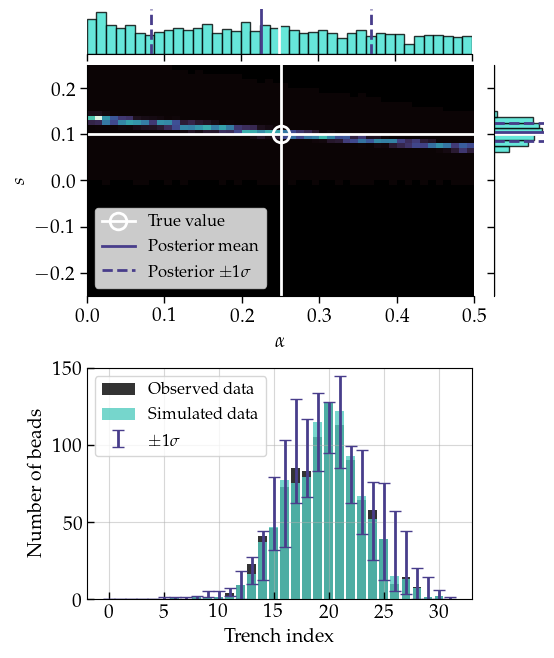

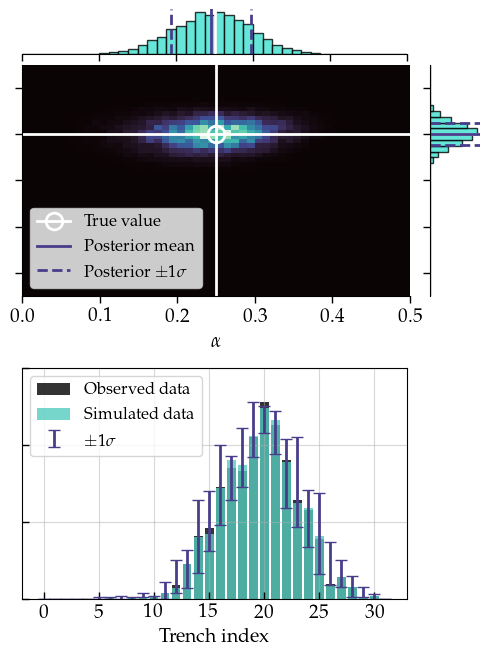

In [ ]:

res_2 = get_ABC_results(results_2, its)
weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, sim_std_minus, sim_std_plus, sim_std_minus_avg, sim_std_plus_avg, ABC_its = res_2.iloc[0]
fig, ax = joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, 'mako', 'white', 'darkslateblue')
ax.set_facecolor('black')

true_counts = vec_dalton_simulator(n_rows, n_cols, n_beads, 0.25, 0.1, disable=True, seed=19)
simulated_counts = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_mean, s_mean, disable=True, seed=19)

ax_bar = fig.add_axes([0.125, -0.9, 0.77, 0.77])
ax_bar = dist_data_plotter(ax_bar, true_counts, simulated_counts, sim_std_minus, sim_std_plus, 32)
ax_bar.set_ylim(0, 150)
# fig.savefig('figs/dalton_ABC_summary_comparison_left.pdf', bbox_inches='tight')

res_4 = get_ABC_results(results_4, its)
weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, sim_std_minus, sim_std_plus, sim_std_minus_avg, sim_std_plus_avg, ABC_its = res_4.iloc[0]
fig, ax = joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, 'mako', 'white', 'darkslateblue')
ax.set_facecolor('black')
ax.set_ylabel('')
ax.set_yticklabels([])

simulated_counts = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_mean, s_mean, disable=True, seed=19)

ax_bar = fig.add_axes([0.125, -0.9, 0.77, 0.77])
ax_bar = dist_data_plotter(ax_bar, true_counts, simulated_counts, sim_std_minus, sim_std_plus, 32)
ax_bar.set_ylim(0, 150)
ax_bar.set_ylabel('')
ax_bar.set_yticklabels([])
# fig.savefig('figs/dalton_ABC_summary_comparison_right.pdf', bbox_inches='tight')

plt.show()


## **Training Neural Network**

In [600]:

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler_Y = StandardScaler()

X = training_data.reshape(-1, n_cols)
X_norm = X / np.sum(X, axis=1, keepdims=True)
Y = np.array([alpha_train.ravel(), s_train.ravel()]).T
Y_scaled = scaler_Y.fit_transform(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X_norm, Y_scaled, train_size=0.9, random_state=67)
mlp = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=5000)

mlp.fit(X_train, Y_train)


MLPRegressor(max_iter=5000)

In [601]:

# Evaluate the model
Y_pred_scaled = mlp.predict(X_test)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
Y_test_inv = scaler_Y.inverse_transform(Y_test)
alpha_err, s_err = np.mean((Y_test_inv - Y_pred) ** 2, axis=0)
print(f'Mean Squared Error on test set: alpha: {alpha_err:.6f}, s: {s_err:.6f}')

its = 100000
y_obs_norm = normalize_trenches(y_obs)
sample = mlp.predict(y_obs_norm.reshape(1, -1))
alpha_pred, s_pred = scaler_Y.inverse_transform(sample)[0]
print(f'Predicted alpha and s from NN: alpha = {alpha_pred:.6f}, s = {s_pred:.6f} ')


Mean Squared Error on test set: alpha: 0.000533, s: 0.000038
Predicted alpha and s from NN: alpha = 0.247001, s = 0.101108 


In [602]:

results_NN_1 = ABC(y_obs, its, summary_choice='mean', h='cal', h_quantile=0.01, cal_its=1000, s_pred=s_pred, s_error=s_err)
results_NN_2 = ABC(y_obs, its, summary_choice='all', h='cal', h_quantile=0.01, cal_its=1000, s_pred=s_pred, s_error=s_err)


Running ABC iterations: 100%|██████████| 100000/100000 [03:20<00:00, 498.11it/s]


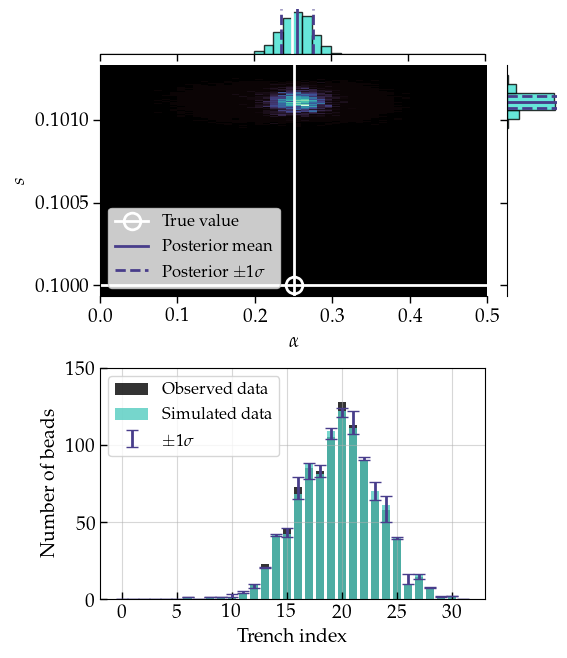

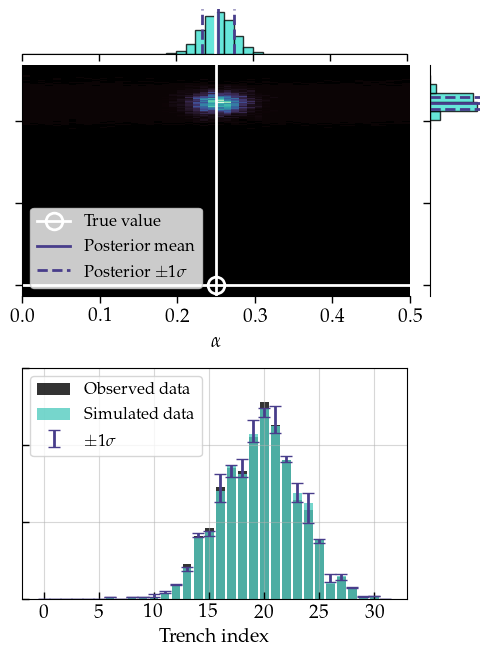

In [605]:

res_1 = get_ABC_results(results_NN_1, its)
weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, sim_std_minus, sim_std_plus, sim_std_minus_avg, sim_std_plus_avg, ABC_its = res_1.iloc[0]
fig, ax = joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, 'mako', 'white', 'darkslateblue')
ax.set_facecolor('black')

true_counts = vec_dalton_simulator(n_rows, n_cols, n_beads, 0.25, 0.1, disable=True, seed=19)
simulated_counts = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_mean, s_mean, disable=True, seed=19)

ax_bar = fig.add_axes([0.125, -0.9, 0.77, 0.77])
ax_bar = dist_data_plotter(ax_bar, true_counts, simulated_counts, sim_std_minus, sim_std_plus, 32)
ax_bar.set_ylim(0, 150)
# fig.savefig('figs/dalton_ABC_summary_comparison_left.pdf', bbox_inches='tight')

res_2 = get_ABC_results(results_NN_2, its)
weights, s_samples, alpha_samples, alpha_mean, alpha_std, s_mean, s_std, sim_std_minus, sim_std_plus, sim_std_minus_avg, sim_std_plus_avg, ABC_its = res_2.iloc[0]
fig, ax = joint_plotter(s_samples, alpha_samples, s_mean, s_std, alpha_mean, alpha_std, weights, 'mako', 'white', 'darkslateblue')
ax.set_facecolor('black')
ax.set_ylabel('')
ax.set_yticklabels([])

simulated_counts = vec_dalton_simulator(n_rows, n_cols, n_beads, alpha_mean, s_mean, disable=True, seed=19)

ax_bar = fig.add_axes([0.125, -0.9, 0.77, 0.77])
ax_bar = dist_data_plotter(ax_bar, true_counts, simulated_counts, sim_std_minus, sim_std_plus, 32)
ax_bar.set_ylim(0, 150)
ax_bar.set_ylabel('')
ax_bar.set_yticklabels([])
# fig.savefig('figs/dalton_ABC_summary_comparison_right.pdf', bbox_inches='tight')

plt.show()

## **Chain of Transformers**

In [606]:

N_transformations = 100
rng = np.random.default_rng(67)
its = 1000

transformation_results = {
    'alpha_mean': [],
    'alpha_std': [],
    's_mean': [],
    's_std': []
}
alpha_mean_trans = None
alpha_std_trans = None
for i in tqdm(range(N_transformations), desc='Performing data transformations and ABC'):
    exp_idx = rng.integers(0, n_trials)
    y_obs_trans = board_data[exp_idx]
    pred_trans = mlp.predict(normalize_trenches(y_obs_trans).reshape(1, -1))
    alpha_pred_trans, s_pred_trans = scaler_Y.inverse_transform(pred_trans)[0]

    trans_result = ABC(y_obs_trans, its, summary_choice='all', h='cal', h_quantile=0.01, cal_its=1000, s_pred=s_pred_trans, s_error=s_err, alpha_mean=alpha_mean_trans, alpha_error=alpha_std_trans, disable=True)
    weights_trans = np.array(trans_result['kernel_value'])
    s_samples_trans = np.array(trans_result['s'])
    alpha_samples_trans = np.array(trans_result['alpha'])
    alpha_mean_trans = np.sum(alpha_samples_trans * weights_trans) / np.sum(weights_trans)
    alpha_std_trans = np.sqrt(np.sum((alpha_samples_trans - alpha_mean_trans)**2 * weights_trans) / np.sum(weights_trans))
    s_mean_trans = np.sum(s_samples_trans * weights_trans) / np.sum(weights_trans)
    s_std_trans = np.sqrt(np.sum((s_samples_trans - s_mean_trans)**2 * weights_trans) / np.sum(weights_trans))
    transformation_results['alpha_mean'].append(alpha_mean_trans)
    transformation_results['alpha_std'].append(alpha_std_trans)
    transformation_results['s_mean'].append(s_mean_trans)
    transformation_results['s_std'].append(s_std_trans)


Performing data transformations and ABC: 100%|██████████| 100/100 [06:26<00:00,  3.86s/it]


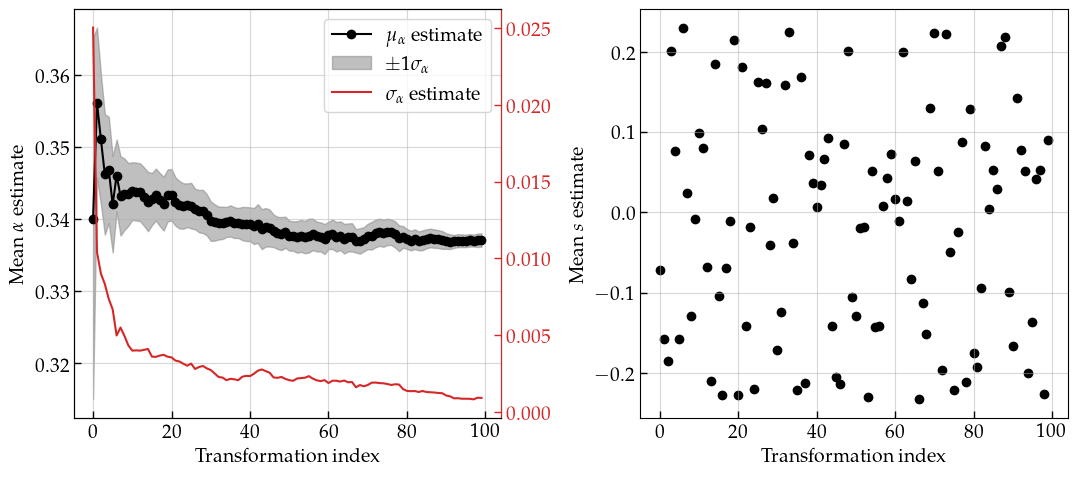

In [607]:

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].plot(np.arange(N_transformations), transformation_results['alpha_mean'], color='k', marker='o', label=r'$\mu_\alpha$ estimate')
axs[0].fill_between(np.arange(N_transformations),
                    np.array(transformation_results['alpha_mean']) - np.array(transformation_results['alpha_std']),
                    np.array(transformation_results['alpha_mean']) + np.array(transformation_results['alpha_std']),
                    color='gray', alpha=0.5, label=r'$\pm 1\sigma_\alpha$')
axs[0].plot([], [], color='tab:red', label=r'$\sigma_\alpha$ estimate')
axs[0].legend()
ax2 = axs[0].twinx()
ax2.tick_params(color='tab:red', labelcolor='tab:red')
ax2.spines['right'].set_color('tab:red')
ax2.plot(np.arange(N_transformations), transformation_results['alpha_std'], color='tab:red')
axs[1].scatter(np.arange(N_transformations), transformation_results['s_mean'], color='k')
axs[0].set_ylabel(r'Mean $\alpha$ estimate')
axs[1].set_ylabel(r'Mean $s$ estimate')
axs[0].set_xlabel('Transformation index')
axs[1].set_xlabel('Transformation index')
axs[0].grid(True, linestyle='-', alpha=0.5)
axs[1].grid(True, linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()


---